# `infer_filter_info`

In an ideal world, we would always have the telescope filter name, telescope facility name, and the instrument name. However, in the real world, we might only have one or two of these things. In this case, we need to make assumptions to derive information about the filte, namely the effective wavelength and transmission function. The goal of this mini python package is to standardize the way we do this.

## Import the Package

In [1]:
from infer_filter_info import infer_filter_info
from astropy import units as u
import matplotlib.pyplot as plt

# The basics

We will go through a few examples for optical filters. In the case where all three of filter, telescope, and instrument are known, the package will just query the SVO filter profile service without making assumptions:

np.float64(5449.340427673902)

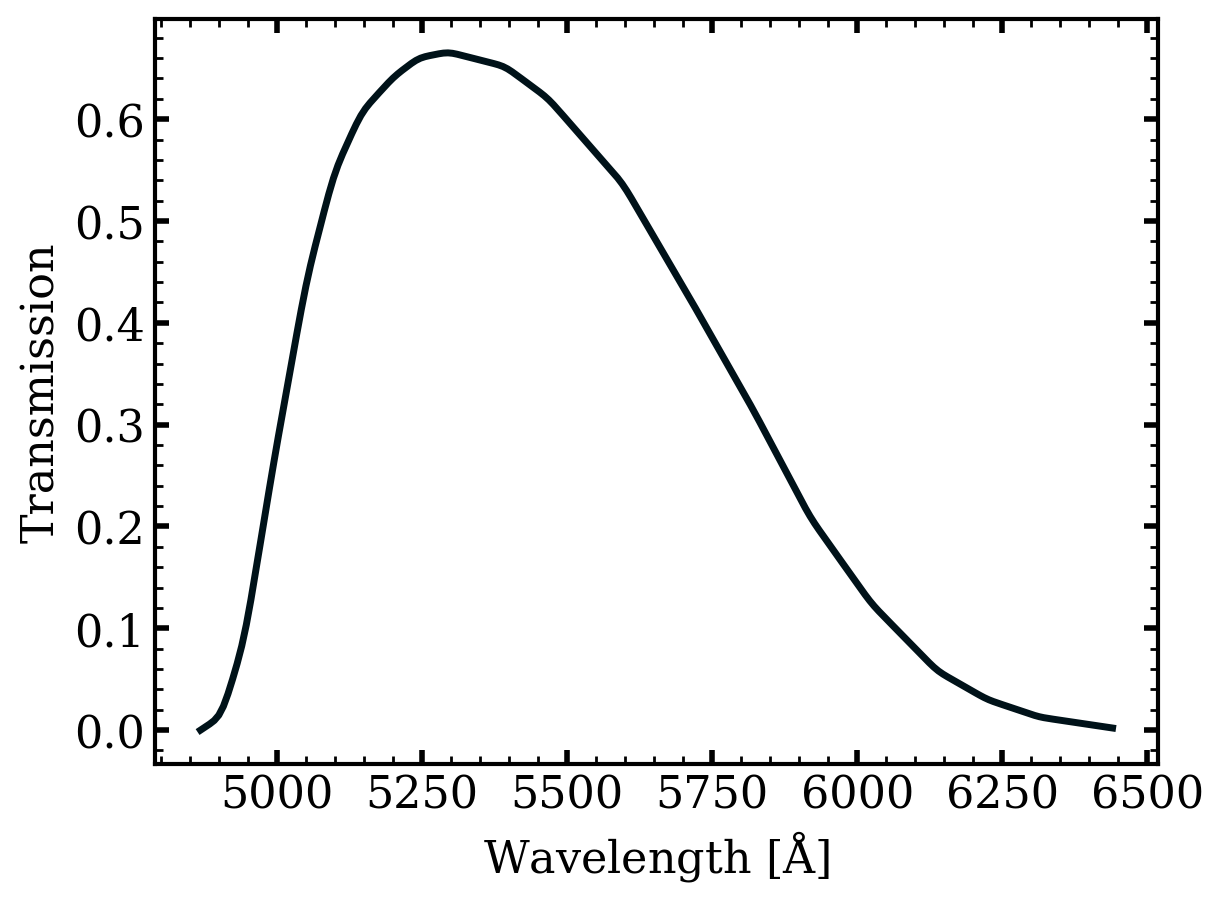

In [2]:
wave_eff_angstroms, (transmission_wave_angstroms, transmission) = infer_filter_info(filter_name="V", telescope="Keck", instrument="ESI")

fig, ax = plt.subplots()
ax.plot(transmission_wave_angstroms, transmission)
ax.set_ylabel("Transmission")
ax.set_xlabel(r"Wavelength [$\AA$]")

wave_eff_angstroms

In the case where the filter name and telescope are known, we can also use this package:

np.float64(5469.061740303522)

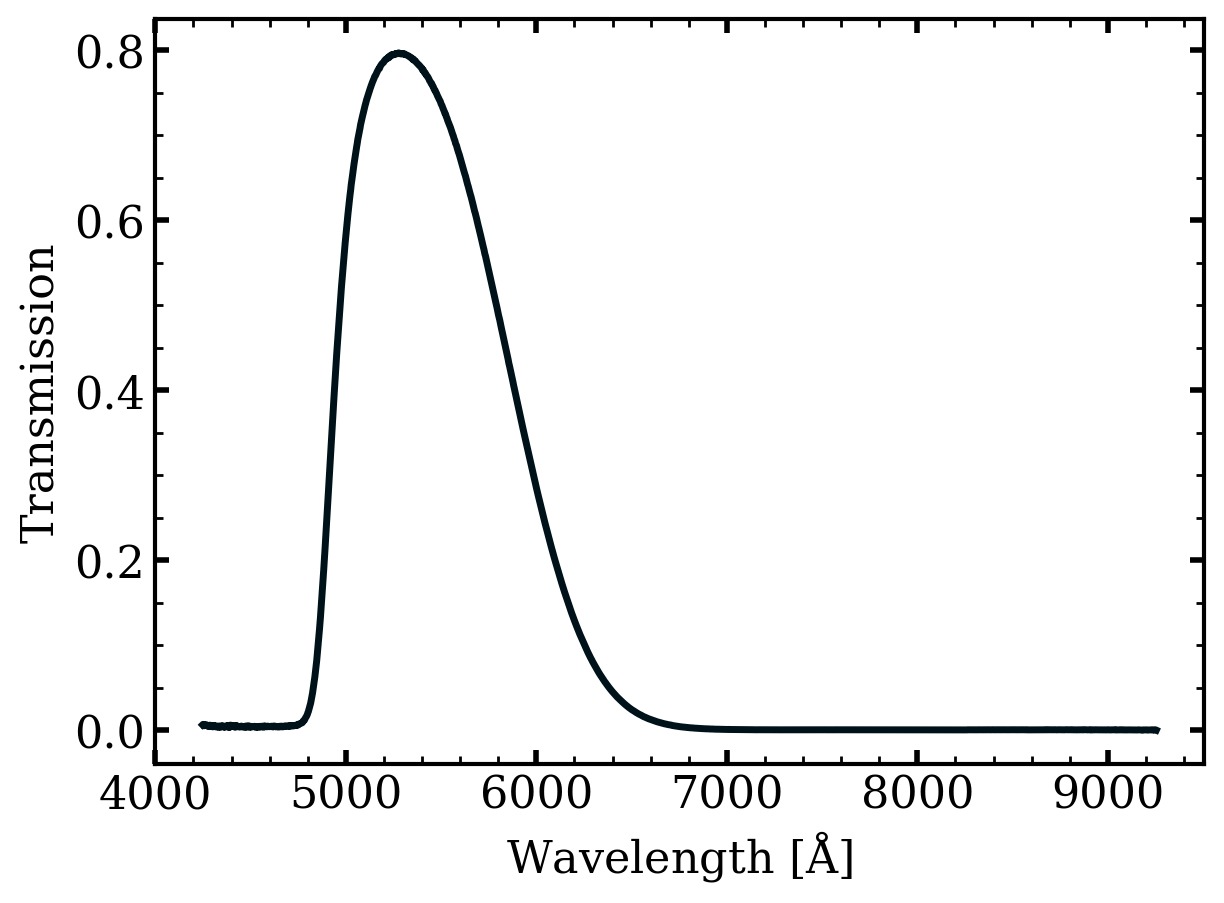

In [3]:
wave_eff_angstroms, (transmission_wave_angstroms, transmission) = infer_filter_info(filter_name="V", telescope="Keck")

fig, ax = plt.subplots()
ax.plot(transmission_wave_angstroms, transmission)
ax.set_ylabel("Transmission")
ax.set_xlabel(r"Wavelength [$\AA$]")

wave_eff_angstroms

BUT, the output looks different!! This is because the code implicitly assumes the V filter is for the Keck LRIS instrument. It is, unfortunately, an assumption that we may occasionally need to make!

In another case, just the filter name might be known to be `V`:

np.float64(5537.155963302752)

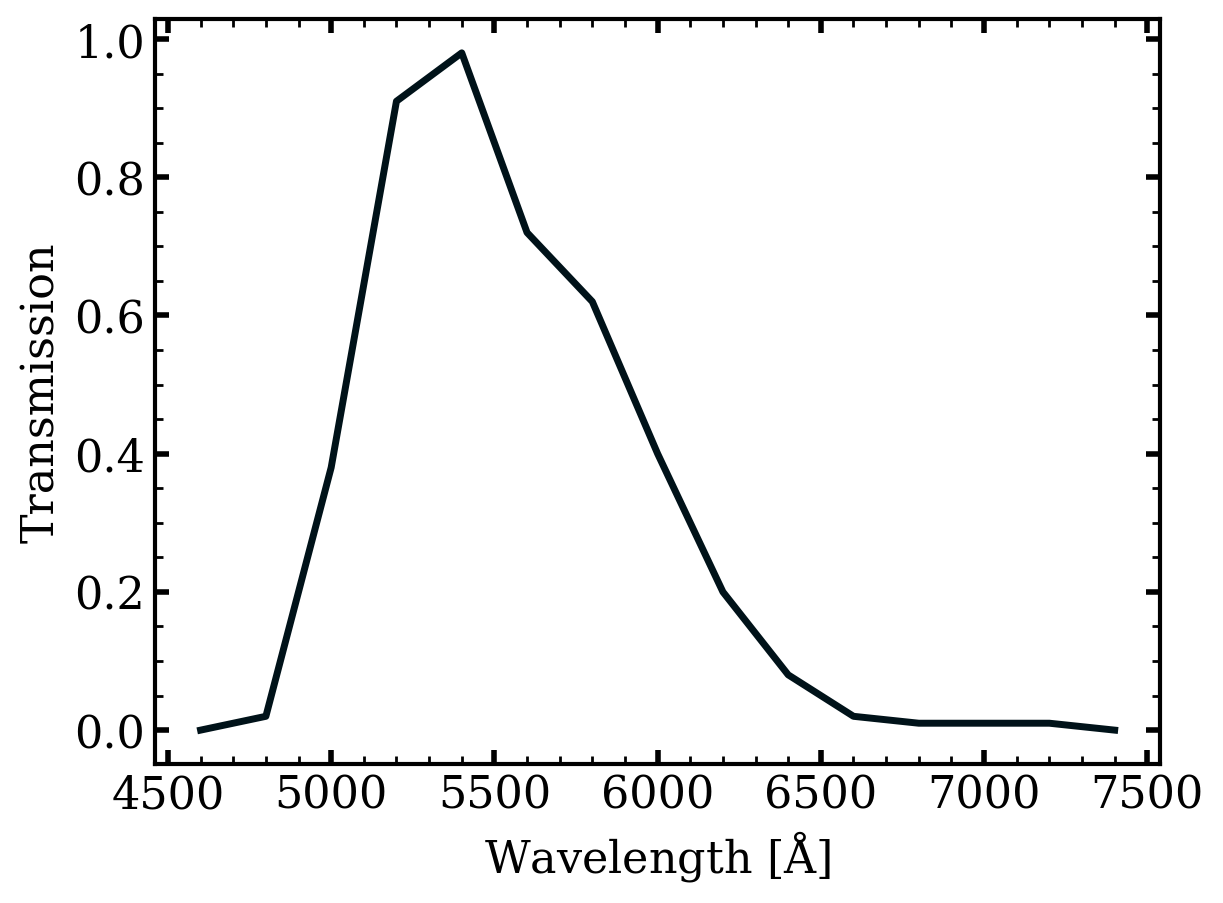

In [4]:
wave_eff_angstroms, (transmission_wave_angstroms, transmission) = infer_filter_info(filter_name="V")

fig, ax = plt.subplots()
ax.plot(transmission_wave_angstroms, transmission)
ax.set_ylabel("Transmission")
ax.set_xlabel(r"Wavelength [$\AA$]")

wave_eff_angstroms

Where then this transmission function is assumed to be the generic Johnson-Cousins V-band transmission. You can also change the output units, let's say we want this in $\mu$m instead of angstroms:

np.float64(0.5537155963302752)

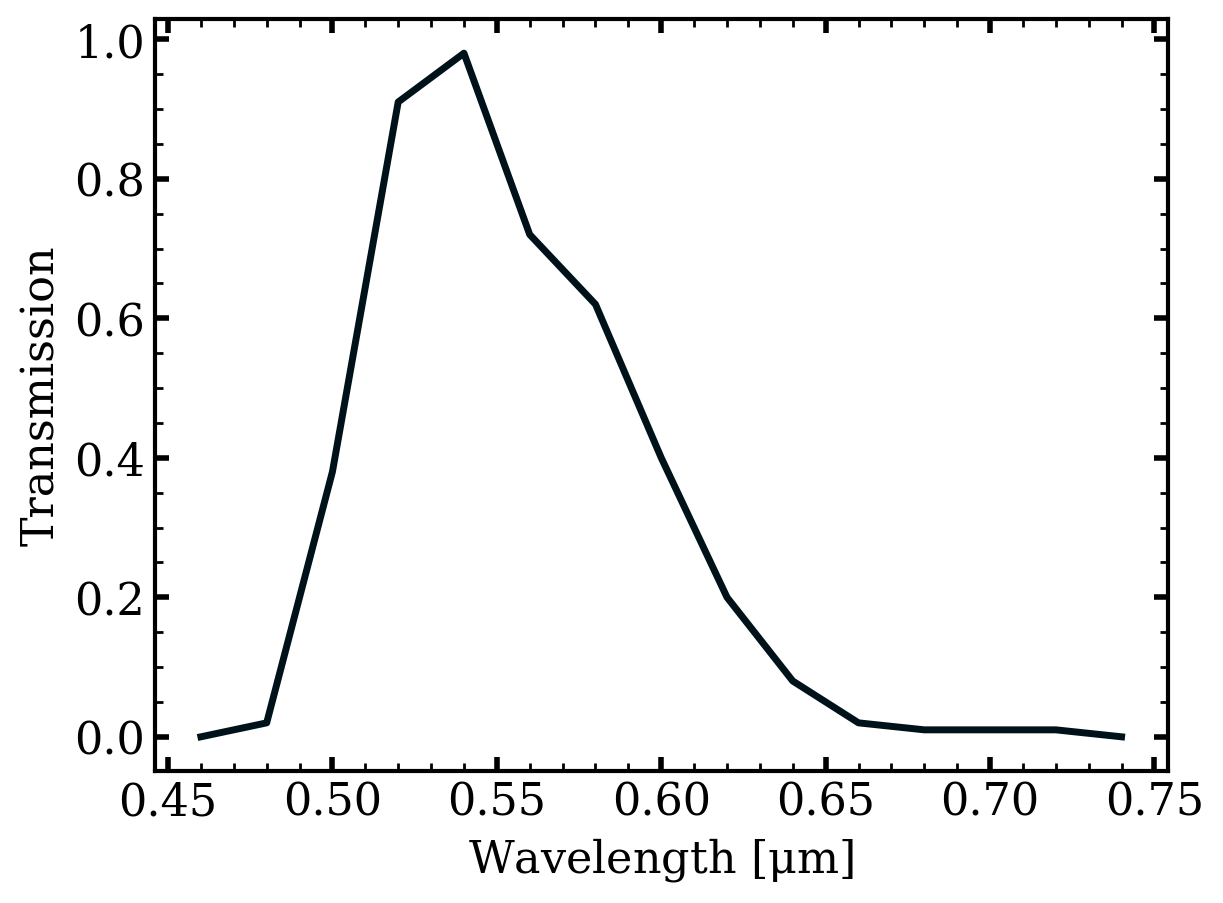

In [5]:
wave_eff_angstroms, (transmission_wave_angstroms, transmission) = infer_filter_info(filter_name="V", out_wave_unit=u.um)

fig, ax = plt.subplots()
ax.plot(transmission_wave_angstroms, transmission)
ax.set_ylabel("Transmission")
ax.set_xlabel(r"Wavelength [$\mu$m]")

wave_eff_angstroms

# Radio Bands
The package can also handle radio bands, for example say we have an observation at VLA X-band. However, the major caveat with this is that it assumes a flat/constant transmission function!

Also note that we can tell it to give us the output in GHz, much more friendly for the radio!

<Quantity 10. GHz>

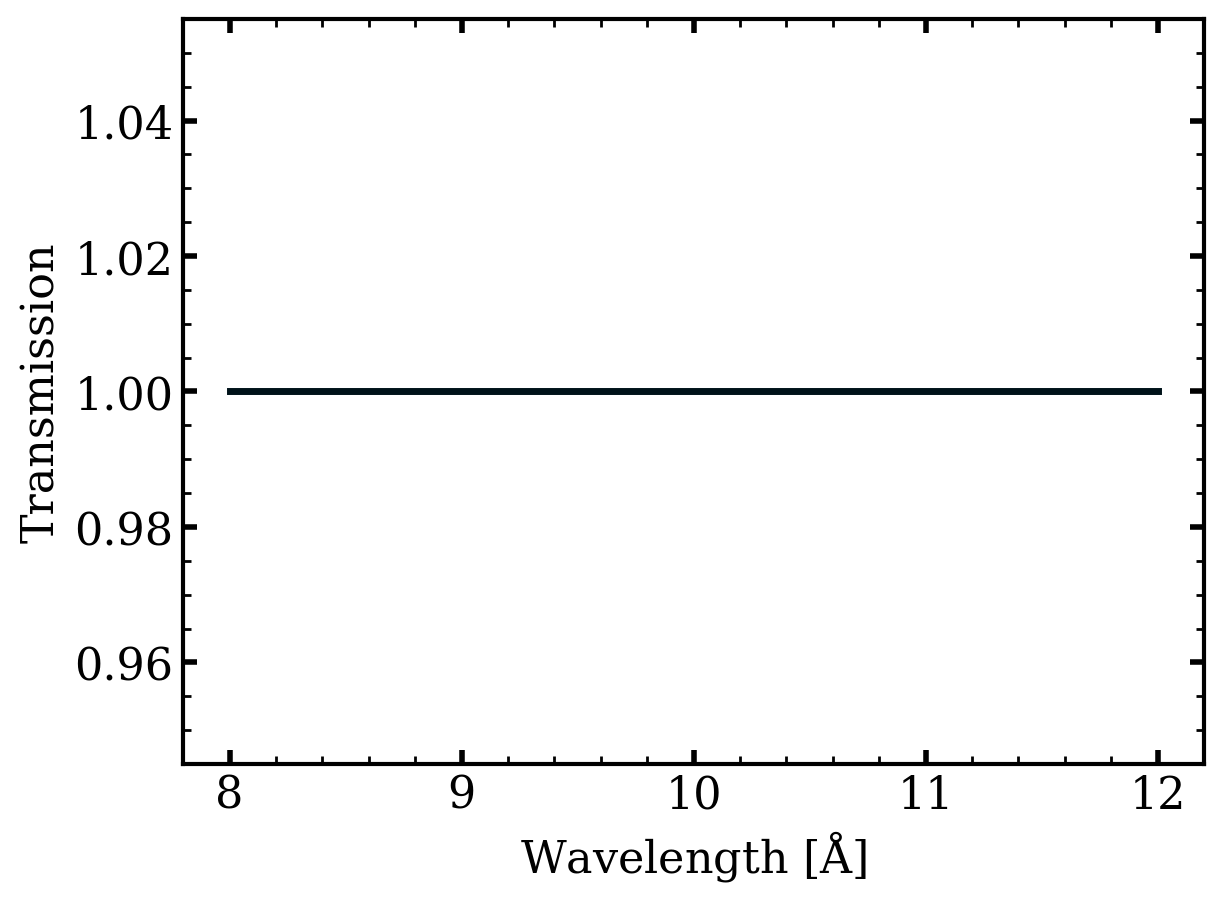

In [6]:
wave_eff_angstroms, (transmission_wave_angstroms, transmission) = infer_filter_info(filter_name="X", out_wave_unit=u.GHz, obs_type="radio")

fig, ax = plt.subplots()
ax.plot(transmission_wave_angstroms, transmission)
ax.set_ylabel("Transmission")
ax.set_xlabel(r"Wavelength [$\AA$]")

wave_eff_angstroms

## Advanced Usage: Customizing the Defaults

You might disagree with our assumptions, so we made it easy for you to customize them. Returning to the Keck example, say that you believe if the `filter_name="V"` and the `telescope="Keck"` the default assumption for the instrument should be `ESI` rather than `LRIS`. To do this you just need to pass in a custom `UvoirFilter` class.

In [11]:
from infer_filter_info.filter_mappings import UvoirFilter

f = UvoirFilter("V", telescope="Keck")
f.wave_eff # this effective wavelength is from the assumed default in the package

np.float64(5469.061740303522)

In [10]:
f.instrument = "ESI" # update the instrument
f.wave_eff # check the effective wavelength again

np.float64(5449.340427673902)